In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
data_dir = '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80622'
fn_list = glob.glob(os.path.join(data_dir, 'zbest-*.fits'))

In [4]:
fn_list

['/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80622/zbest-8-80622.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80622/zbest-5-80622.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80622/zbest-3-80622.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80622/zbest-9-80622.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80622/zbest-2-80622.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80622/zbest-4-80622.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80622/zbest-7-80622.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80622/zbest-1-80622.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80622/zbest-0-80622.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80622/zbest-6-80622.fits']

In [5]:
zbest = []
for fn in fn_list:
    tmp1 = Table.read(fn, hdu='ZBEST')
    tmp2 = Table.read(fn, hdu='FIBERMAP')
    tmp = join(tmp1, tmp2, keys='TARGETID', metadata_conflicts='silent')
    zbest.append(tmp)
zbest = vstack(zbest)
print(len(zbest))

5000


In [6]:
zbest[:5]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKID,BRICK_OBJID,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,BRICKNAME,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int32,float64,int32,int16,int32,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,bytes8,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64
39628511589174632,8.999999999999996e+99,0.0 .. 0.0,-0.0019957014509158224,4.131159871613317e-48,1570,0,STAR,CV,3,1.942668892225729e+84,0,0,8,351,8351,4192,512,156.23854771457917,31.600396382324348,0.0,0.0,2020.9651,5400.0,824700830531,1,TGT,-263.1489,-179.66136,3200,0.5418106218657233,3,9010,503665,3432,REX,0.8407827,1.4283084,4.1415324,583.2592,249.29663,24.96296,0,,0.0,0.0,0.0,0.0,1561p315,0.021960782,30.60585,25.300814,0.28849816,0.4900961,1.421086,0.2885136,0.49012384,1.4211224,0,1.0,0.8252879,0.0,0.0,S,3200,1,824700830531,0,0,0,0,0,2,nan,nan,nan,nan,0.0,0.0,0,nan,nan,4192,4192,1
39628511589174747,8.999999999999996e+99,0.0 .. 0.0,-0.0019957014509158224,4.131159871613317e-48,1570,0,STAR,CV,3,1.942668892225729e+84,0,0,8,372,8372,4168,512,156.24558400389185,31.574433323683905,0.0,0.0,2020.9651,5400.0,9292797400071942,1,TGT,-264.94028,-186.28748,3400,0.573552426052713,3,9010,503665,3547,PSF,0.93426734,1.5287802,2.6776822,1527.4331,756.7926,111.01584,0,,0.0,0.0,0.0,0.0,1561p315,0.021675797,12.392592,14.555789,0.72752726,1.190483,2.0851493,0.72752726,1.190483,2.0851493,0,0.0,0.0,0.0,0.0,S,3400,1,9292797400071942,0,0,0,0,0,2,nan,nan,nan,nan,0.0,0.0,0,nan,nan,4168,4168,1
39628511589175313,13866.275534629822,-37.61467077160063 .. -4.41939824970452,1.5668002221168216,2.5517956003570794e-05,0,7757,GALAXY,,10,244.2919340133667,0,0,8,371,8371,4179,0,156.2821490148787,31.60333907968922,0.0,0.0,2020.9651,5400.0,36032920187604742,1,TGT,-272.7544,-179.0537,3400,0.029069501435756928,3,9010,503665,4113,PSF,0.58550495,0.67685646,0.91561353,1724.682,704.83154,107.296776,0,,0.0,0.0,0.0,0.0,1561p315,0.02124119,2.0998898,0.2716196,0.45535305,0.526398,0.7120818,0.45535317,0.52639824,0.7120822,0,0.0,0.0,0.0,0.0,S,3400,1,36032920187604742,0,0,0,0,0,2,-272.686,-179.016,-0.0006666666666666666,-0.002333333333333333,0.0,0.0,6,0.004,0.0052915026221291815,4179,4179,1
39628511593365814,10199.422167879424,4341.406568458901 .. 0.0,-0.0002597742514561394,4.316967409188877e-06,0,7756,STAR,F,5,22339.13778397667,0,0,8,393,8393,4159,0,156.30793563569995,31.587680165703166,3.0879145,-8.010371,2020.9651,5400.0,2305843017803628544,3,TGT,-278.62,-183.12682,1100,0.48346539674181954,7,9010,503666,310,PSF,46.889896,58.89313,60.84132,261.3725,143.0527,51.373055,747981748737977216,G2,18.109884,18.358885,17.671202,0.24114147,1564p315,0.020519296,14.015975,5.689341,36.443302,45.77234,47.28649,36.443302,45.77234,47.28649,0,0.0,0.0,0.0,0.0,S,1100,1,2305843017803628544,0,33,0,0,0,2,-278.547,-183.089,-0.003999999999999999,

In [7]:
# SV1 target bits
bitvalues = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 53, 54, 55, 56, 57, 32, 33, 34, 35, 36, 37, 49, 50, 51, 52, 60, 61, 62]
bitnames = ['LRG', 'ELG', 'QSO', 'LRG_OPT', 'LRG_IR', 'LRG_SV_OPT', 'LRG_SV_IR', 'LOWZ_FILLER', 'ELG_SV_GTOT', 'ELG_SV_GFIB', 'ELG_FDR_GTOT', 'ELG_FDR_GFIB', 'QSO_COLOR_4PASS', 'QSO_RF_4PASS', 'QSO_COLOR_8PASS', 'QSO_RF_8PASS', 'QSO_HZ_F', 'QSO_Z5', 'LRG_OPT_NORTH', 'LRG_IR_NORTH', 'LRG_SV_OPT_NORTH', 'LRG_SV_IR_NORTH', 'LOWZ_FILLER_NORTH', 'LRG_OPT_SOUTH', 'LRG_IR_SOUTH', 'LRG_SV_OPT_SOUTH', 'LRG_SV_IR_SOUTH', 'LOWZ_FILLER_SOUTH', 'ELG_SV_GTOT_NORTH', 'ELG_SV_GFIB_NORTH', 'ELG_FDR_GTOT_NORTH', 'ELG_FDR_GFIB_NORTH', 'ELG_SV_GTOT_SOUTH', 'ELG_SV_GFIB_SOUTH', 'ELG_FDR_GTOT_SOUTH', 'ELG_FDR_GFIB_SOUTH', 'QSO_COLOR_4PASS_NORTH', 'QSO_RF_4PASS_NORTH', 'QSO_COLOR_8PASS_NORTH', 'QSO_RF_8PASS_NORTH', 'QSO_HZ_F_NORTH', 'QSO_Z5_NORTH', 'QSO_COLOR_4PASS_SOUTH', 'QSO_RF_4PASS_SOUTH', 'QSO_COLOR_8PASS_SOUTH', 'QSO_RF_8PASS_SOUTH', 'QSO_HZ_F_SOUTH', 'QSO_Z5_SOUTH', 'SKY', 'STD_FAINT', 'STD_WD', 'STD_BRIGHT', 'BAD_SKY', 'SUPP_SKY', 'NO_TARGET', 'BRIGHT_OBJECT', 'IN_BRIGHT_OBJECT', 'NEAR_BRIGHT_OBJECT', 'BGS_ANY', 'MWS_ANY', 'SCND_ANY']

def bitmask_summary(mask_values, names, bits):
    mask_values = np.array(mask_values, dtype=np.uint64)
    t = Table()
    t['name'] = names
    t['bit'] = bits
    t['count'] = 0
    for index in range(len(bits)):
        bit = bits[index]
        t['count'][index] = np.sum(mask_values & (2**bit)>0)
    t['frac (%)'] = t['count']/len(mask_values)*100
    t['frac (%)'].format = "%.3f"
    return t

In [8]:
t = bitmask_summary(zbest['SV1_DESI_TARGET'], bitnames, bitvalues)
t.pprint(max_lines=-1)

         name         bit count frac (%)
--------------------- --- ----- --------
                  LRG   0  1900   38.000
                  ELG   1  1364   27.280
                  QSO   2  1731   34.620
              LRG_OPT   3   493    9.860
               LRG_IR   4   533   10.660
           LRG_SV_OPT   5  1368   27.360
            LRG_SV_IR   6  1646   32.920
          LOWZ_FILLER   7     0    0.000
          ELG_SV_GTOT   8  1127   22.540
          ELG_SV_GFIB   9  1241   24.820
         ELG_FDR_GTOT  10   593   11.860
         ELG_FDR_GFIB  11   705   14.100
      QSO_COLOR_4PASS  12   476    9.520
         QSO_RF_4PASS  13   902   18.040
      QSO_COLOR_8PASS  14   195    3.900
         QSO_RF_8PASS  15   420    8.400
             QSO_HZ_F  16   296    5.920
               QSO_Z5  17    50    1.000
        LRG_OPT_NORTH  18   235    4.700
         LRG_IR_NORTH  19   232    4.640
     LRG_SV_OPT_NORTH  20   652   13.040
      LRG_SV_IR_NORTH  21   789   15.780
    LOWZ_FILLER_

In [9]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = zbest['SV1_DESI_TARGET'] & 2**0>0
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

ts_sky = (zbest['DESI_TARGET'] & 2**32>0)
print(np.sum(ts_sky))

493
533
1900

1731
36
2
800


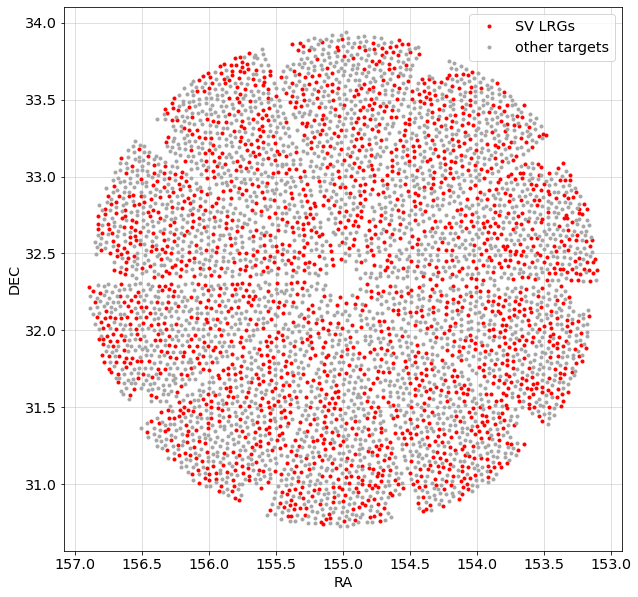

In [10]:
# mask = np.ones(len(zbest), dtype=bool)
plt.figure(figsize=(10, 10))
plt.plot(zbest['TARGET_RA'][lrg_sv], zbest['TARGET_DEC'][lrg_sv], 'r.', ms=6, label='SV LRGs')
plt.plot(zbest['TARGET_RA'][~lrg_sv], zbest['TARGET_DEC'][~lrg_sv], '.', ms=6, label='other targets', color='0.65', alpha=1)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [11]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']!=0
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[~mask]

# Remove "no data" fibers
nodata = zbest['ZWARN'] & 2**9>0
print(np.sum(nodata), np.sum(~nodata), np.sum(nodata)/len(nodata))
zbest = zbest[~nodata]

print(len(zbest))

1051 3949 0.2102
0 3949 0.0
3949


In [12]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

386
418
1500

1389
30
2


In [13]:
mask_zwarn = zbest['ZWARN']==0
print(np.sum((~mask_zwarn) & lrg_opt), np.sum((~mask_zwarn) & lrg_opt)/np.sum(lrg_opt))
print(np.sum((~mask_zwarn) & lrg_ir), np.sum((~mask_zwarn) & lrg_ir)/np.sum(lrg_ir))
print(np.sum((~mask_zwarn) & lrg_sv), np.sum((~mask_zwarn) & lrg_sv)/np.sum(lrg_sv))

0 0.0
0 0.0
12 0.008


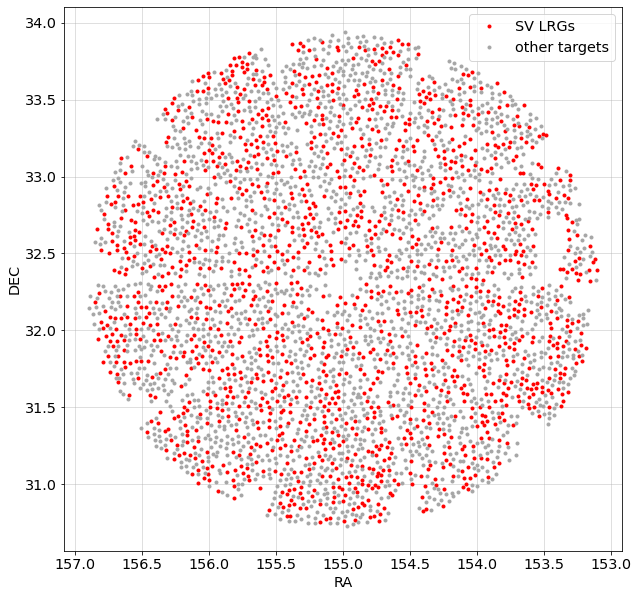

In [14]:
# mask = np.ones(len(zbest), dtype=bool)
plt.figure(figsize=(10, 10))
plt.plot(zbest['TARGET_RA'][lrg_sv], zbest['TARGET_DEC'][lrg_sv], 'r.', ms=6, label='SV LRGs')
plt.plot(zbest['TARGET_RA'][~lrg_sv], zbest['TARGET_DEC'][~lrg_sv], '.', ms=6, label='other targets', color='0.65', alpha=1)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

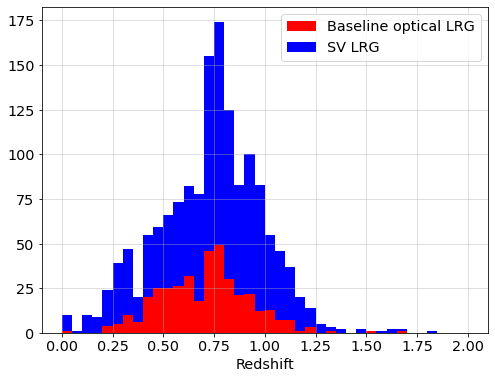

In [15]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

No ZWARN cut:


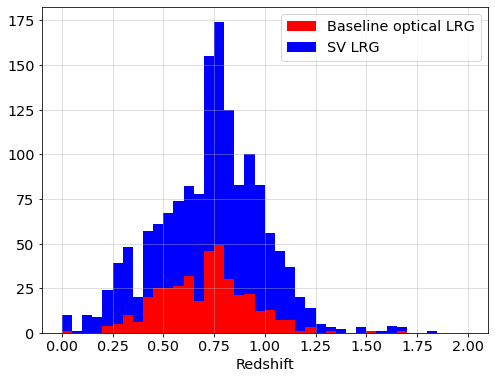

In [16]:
print('No ZWARN cut:')
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

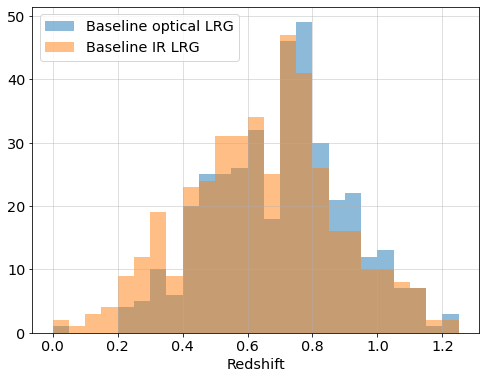

In [17]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=25, range=(0, 1.25), label=['Baseline optical LRG'], alpha=0.5)
plt.hist(zbest['Z'][lrg_ir & mask_zwarn], bins=25, range=(0, 1.25), label=['Baseline IR LRG'], alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.show()

--------
# Stellar contamination

In [18]:
print('LRG_OPT:')
mask = lrg_opt & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_OPT:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,383,99.2
QSO,2,0.5
STAR,1,0.3


In [19]:
print('LRG_IR:')
mask = lrg_ir & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_IR:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,408,97.6
QSO,8,1.9
STAR,2,0.5


In [20]:
print('LRG_SV:')
mask = lrg_sv & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_SV:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,1446,97.2
QSO,29,1.9
STAR,13,0.9


In [21]:
mask_star = zbest['SPECTYPE']=='STAR'
mask_gal = zbest['SPECTYPE']=='GALAXY'
mask_qso = zbest['SPECTYPE']=='QSO'

In [22]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

13
6


In [23]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

1
0


In [24]:
mask = lrg_sv & mask_star & mask_zwarn
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKID,BRICK_OBJID,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,BRICKNAME,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int32,float64,int32,int16,int32,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,bytes8,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64
39628527007436628,3678037.843761148,-191253.25512839976 .. 0.0,-2.293013455939862e-05,1.3876093612242984e-07,0,7710,STAR,M,5,14967047.671394644,0,0,8,64,8064,4325,0,155.7478439666245,32.22381011379758,19.78166,17.317165,2020.9651,5400.0,67108929,1,TGT,-154.7228,-24.37969,3200,0.7554221189206076,1,9010,507341,3924,PSF,555.94116,2021.0543,2626.185,24.28487,1.9346454,0.023592722,748822054794896384,G2,13.999523,15.238559,12.897601,13.398059,1556p322,0.017995523,5370.225,3352.2512,425.75528,1547.7799,2011.2058,425.75528,1547.7799,2011.2058,2200,0.0,0.0,0.0,0.0,S,3200,1,67108929,0,0,0,0,0,2,-154.692,-24.371,0.0013333333333333333,0.0015000000000000002,0.0,0.0,6,0.0051639777949432225,0.0049497474683058325,4325,4325,1
39632950467234191,223937.7689765548,-6136.016121239192 .. 0.0,6.42410486658219e-05,6.989010641405601e-07,0,7737,STAR,M,5,275691.1610757256,0,0,5,324,5324,2887,0,155.08269163218344,33.556868790742215,0.0,0.0,2020.9651,5400.0,2097217,1,TGT,-17.505661,306.9565,3200,0.8797405966013618,1,9011,513400,2447,REX,-0.16409323,1.4857492,4.211923,165.46725,26.839518,1.8963531,0,,0.0,0.0,0.0,0.0,1550p335,0.021851324,25.523064,8.956075,0.0,1.114359,3.159076,12.618439,49.705696,154.29344,144,1.0,0.13245896,0.0,0.0,N,3200,1,2097217,0,0,0,0,0,2,-17.509,306.89,0.0,-0.001,0.0,0.0,6,0.005627314338711377,0.005887840577551898,2887,2887,1
39628501233435710,13942.177279036618,-65.48828810098993 .. 0.0,0.0003499956345342801,2.3217117026807178e-05,0,7749,STAR,M,5,202.18574492248263,0,0,9,392,9392,4794,0,155.59986564245338,31.087015259119195,0.0,0.0,2020.9651,5400.0,67108929,1,TGT,-128.27043,-309.68384,3200,0.6859098000896775,1,9010,501196,1086,PSF,0.13869713,0.62377274,2.2950625,1861.7988,452.45654,77.76674,0,,0.0,0.0,0.0,0.0,1556p310,0.024876377,11.822335,4.109593,0.10781531,0.48488572,1.7840519,0.10781531,0.48488572,1.7840519,0,0.0,0.0,0.0,0.0,S,3200,1,67108929,0,0,0,0,0,2,-128.26,-309.614,0.0014999999999999998,-0.0045000000000000005,0.0,0.0,6,0.00609644705272396,0.006442049363362563,4794,4794,1
39628521877803343,44696.47564446732,1827.3561604499612 .. 0.0,5.003263026294774e-05,1.439638512126642e-06,0,7736,STAR,K,5,56202.32288629011,0,0,9,63,9063,4699,0,155.57000866252025,31.899813898592566,0.0,0.0,2020.9651,5400.0,1297036692808663165,1,TGT,-118.265236,-103.82372,3400,0.763435023282448,5,9010,506118,4431,PSF,1.0696349,6.8484125,20.612947,640.93097,96.68544,1.2550247,0,,0.0,0.0,0.0,0.0,1554p320,0.020030547,84.6366,72.66847,0.8324229,5.329646,16.041634,5.610833,19.142714,48.659805,128,0.0,0.0,

In [25]:
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [26]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2'])
    zbest['gmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_G'])/zbest['FLUX_G']
    zbest['rmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_R'])/zbest['FLUX_R']
    zbest['zmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_Z'])/zbest['FLUX_Z']
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z'])

zbest['z_phot'] = zbest['Z']

385


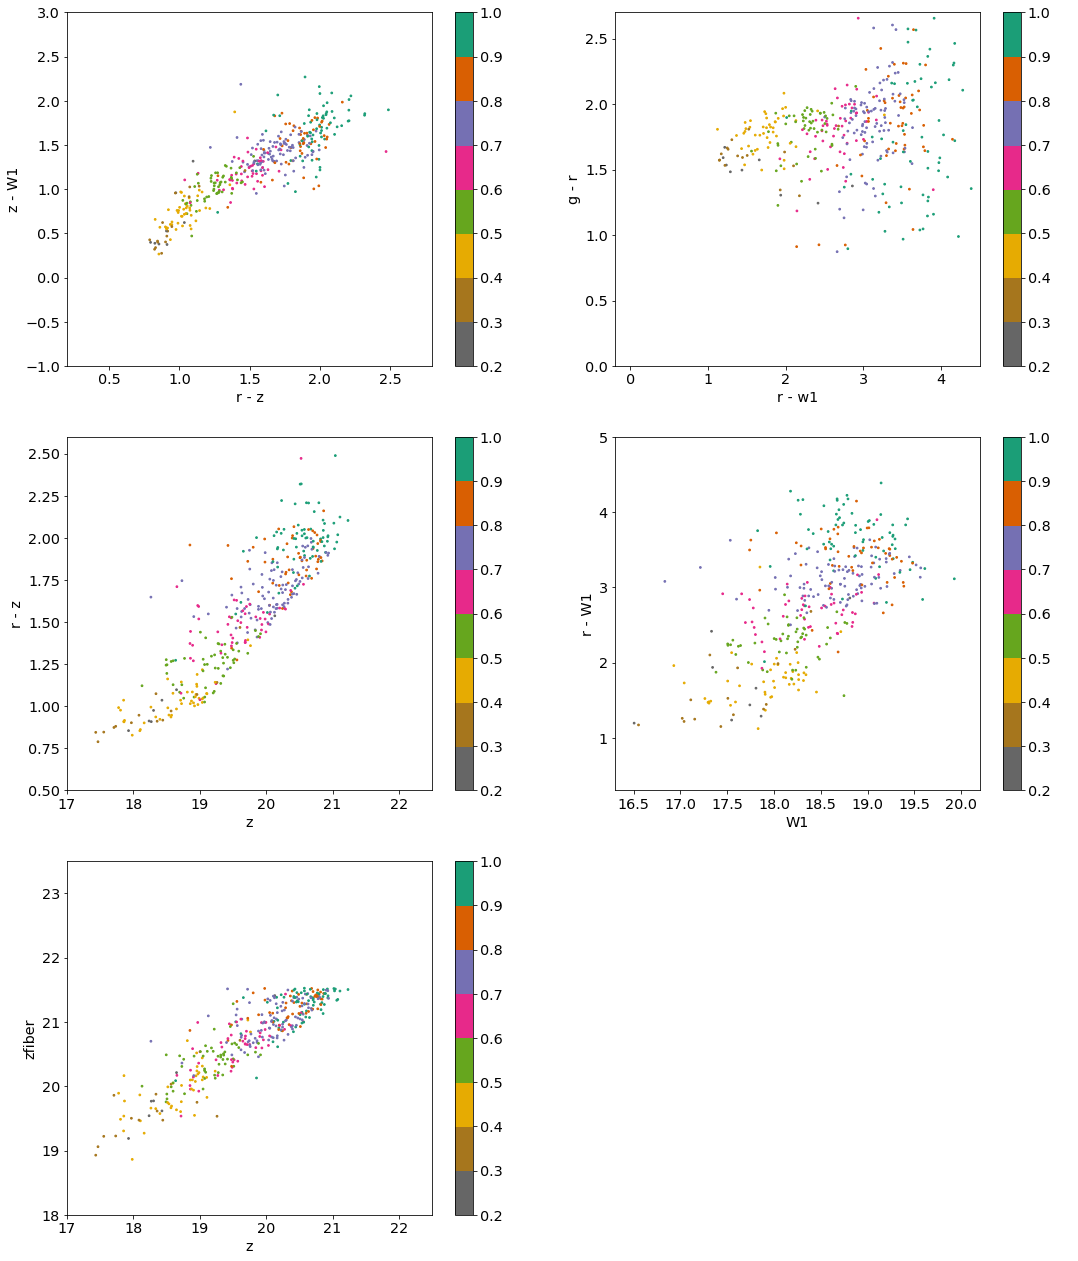

In [27]:
mask = lrg_opt & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=3)

1


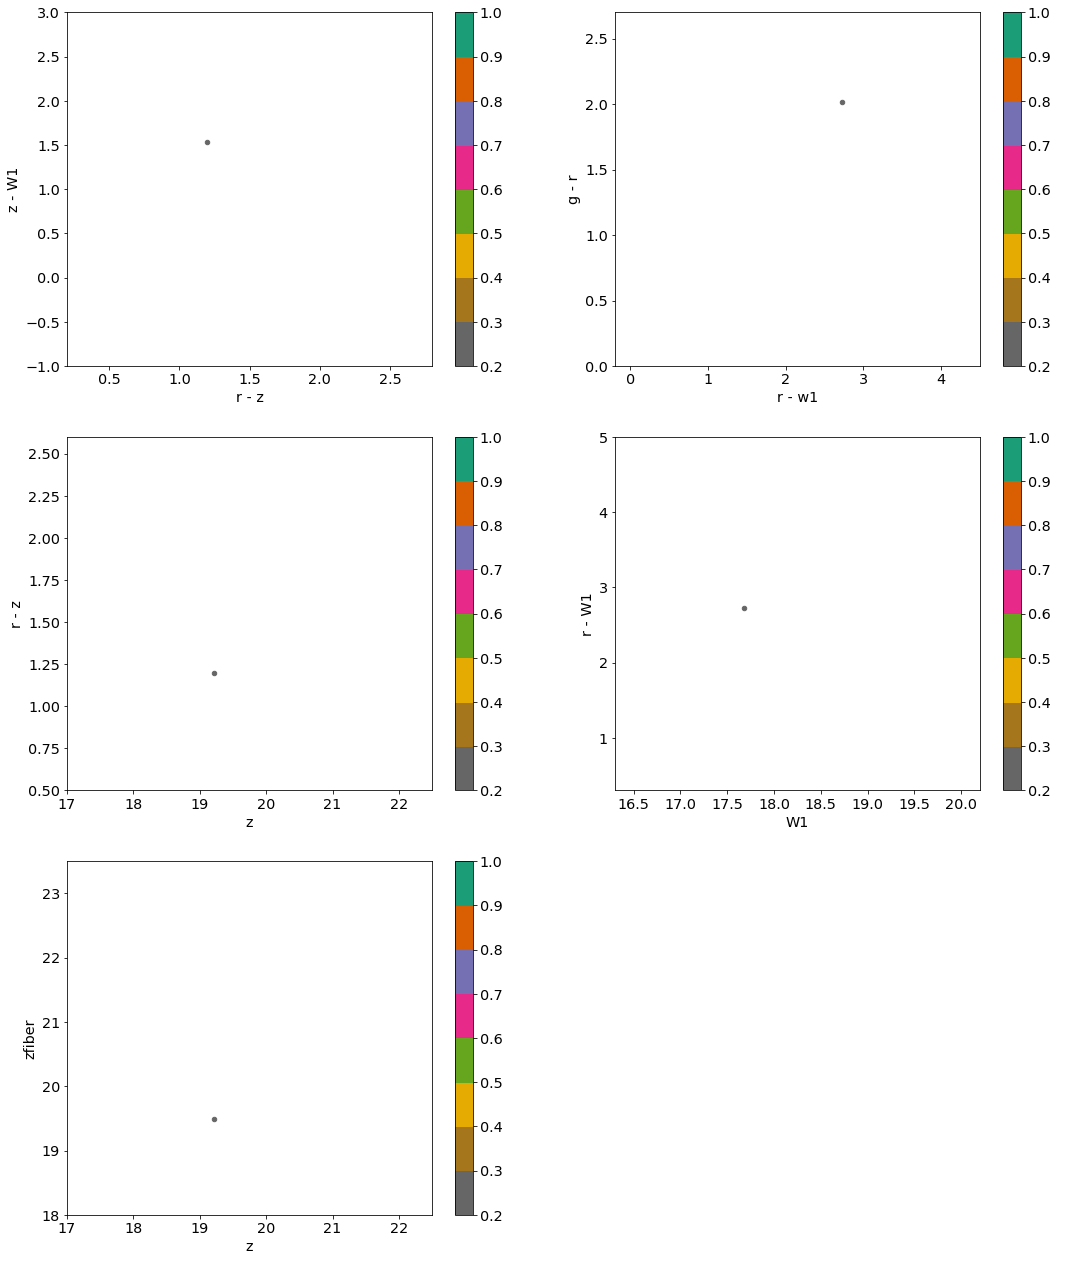

In [28]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=20)

1475


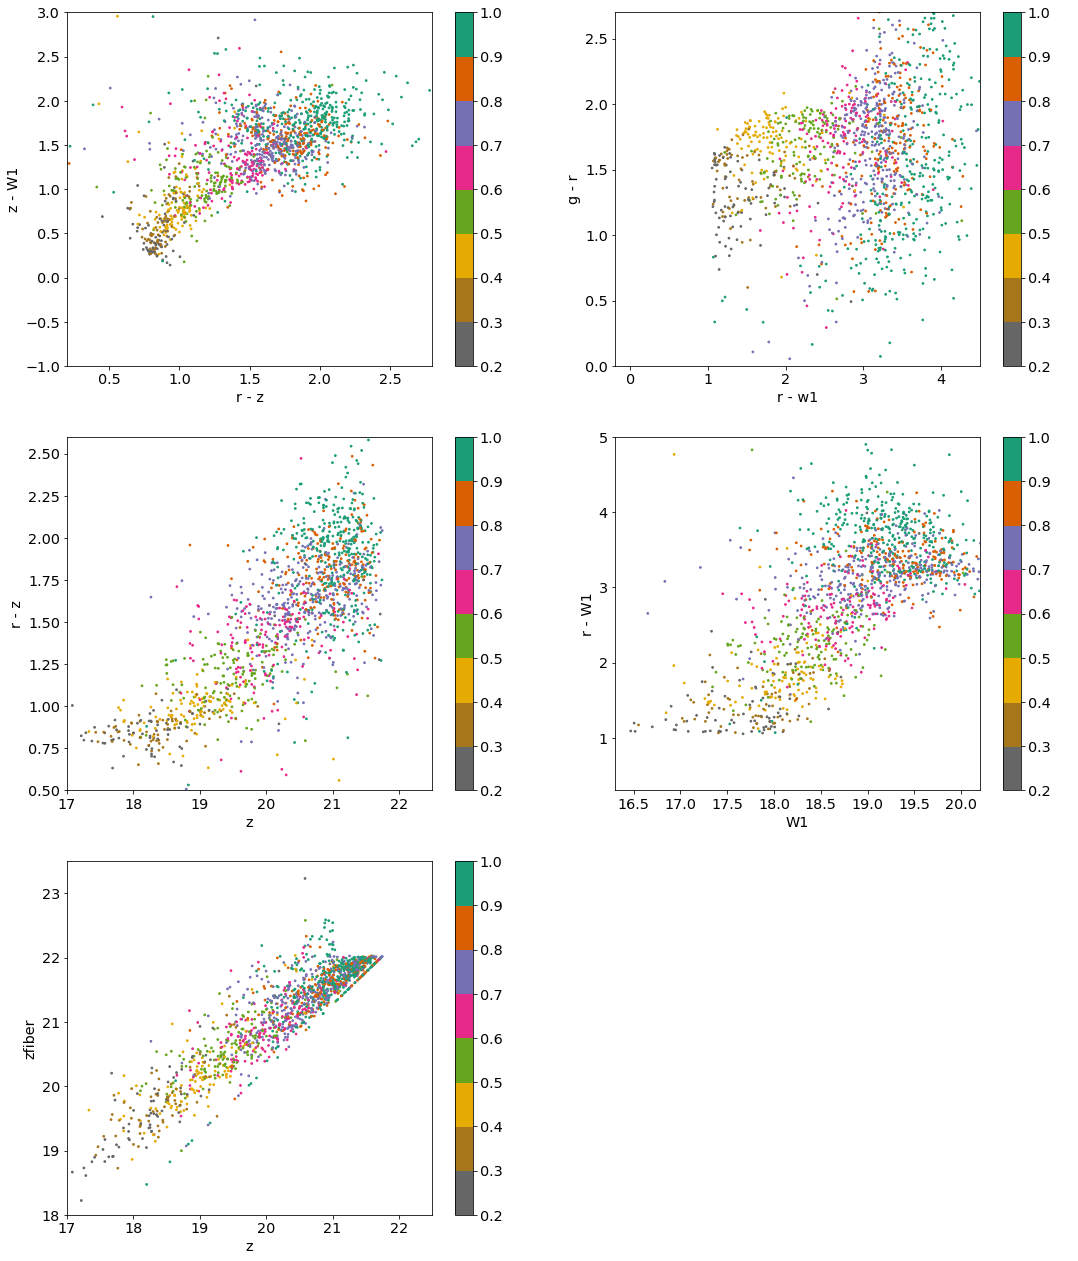

In [29]:
mask = lrg_sv & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=3)

13


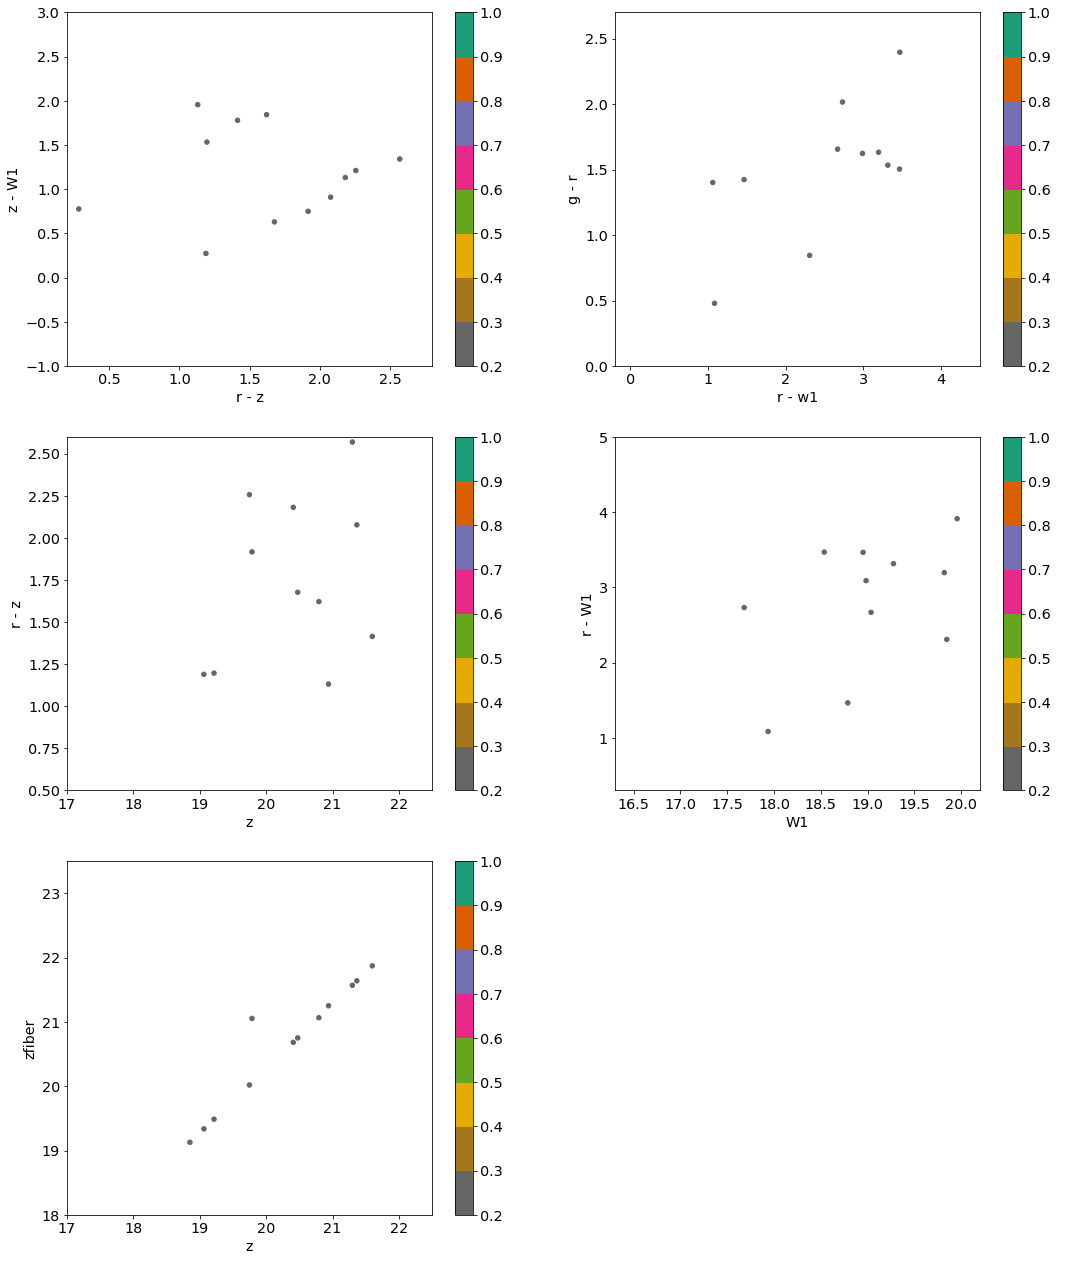

In [30]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=20)

In [31]:
mask = lrg_opt & mask_star & mask_zwarn
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKID,BRICK_OBJID,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,BRICKNAME,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int32,float64,int32,int16,int32,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,bytes8,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
39628521877803343,44696.47564446732,1827.3561604499612 .. 0.0,5.003263026294774e-05,1.439638512126642e-06,0,7736,STAR,K,5,56202.32288629011,0,0,9,63,9063,4699,0,155.57000866252025,31.899813898592566,0.0,0.0,2020.9651,5400.0,1297036692808663165,1,TGT,-118.265236,-103.82372,3400,0.763435023282448,5,9010,506118,4431,PSF,1.0696349,6.8484125,20.612947,640.93097,96.68544,1.2550247,0,,0.0,0.0,0.0,0.0,1554p320,0.020030547,84.6366,72.66847,0.8324229,5.329646,16.041634,5.610833,19.142714,48.659805,128,0.0,0.0,0.0,0.0,S,3400,1,1297036692808663165,1048592,0,0,0,0,2,-118.253,-103.8,0.0015000000000000002,0.00033333333333333365,0.0,0.0,6,0.005369667897862337,0.005066228051190221,4699,4699,1,22.42691,20.411026,19.21465,17.681105,17.846634,0.036928255,0.014850106,0.043304574,20.683254,19.486877,5.003263026294774e-05


In [32]:
mask = lrg_opt & mask_zwarn
mask &= zbest['MASKBITS'] & 2**8>0
print(np.sum(mask))
zbest[mask]

4


TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKID,BRICK_OBJID,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,BRICKNAME,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int32,float64,int32,int16,int32,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,bytes8,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
39628511580784982,15883.748798131943,289.9997122291761 .. -2.0893796726453364,0.4624037746149876,4.704486370362535e-05,0,7757,GALAXY,,10,2925.277904421091,0,0,9,172,9172,4957,0,155.56419752818306,31.534972495781037,0.0,0.0,2020.9651,5400.0,1152921504732676217,1,TGT,-118.28806,-194.49347,3200,0.9269824826606446,7,9010,503663,2390,DEV,2.0303528,10.902414,28.178389,719.6426,225.69154,36.723305,0,,0.0,0.0,0.0,0.0,1555p315,0.02537462,57.461647,31.104954,0.74918836,4.0229273,10.397661,0.74918836,4.0229273,10.397661,2304,4.0,0.9846097,0.04119694,-0.16885066,S,3200,1,1152921504732676217,65537,0,0,0,0,2,-118.279,-194.452,-0.0003333333333333332,-0.001,0.0,0.0,6,0.0058309518948452994,0.005131601439446885,4957,4957,1,21.731071,19.906193,18.87521,18.101555,18.767925,0.01835989,0.006105478,0.0058561605,20.988644,19.95766,0.4624037746149876
39628511555618730,16756.15902379155,163.11521649869005 .. -11.454190530829463,0.4208767638315874,3.272564927580854e-05,0,7758,GALAXY,,10,2697.834264308214,0,0,1,413,1413,986,0,153.79888282997172,31.41880203563772,0.0,0.0,2020.9651,5400.0,1152921504732676217,1,TGT,257.1335,-225.4012,3200,0.8251945721159718,5,9010,503657,1962,DEV,7.5707636,31.160624,71.857864,119.41719,32.974964,4.4362154,0,,0.0,0.0,0.0,0.0,1538p315,0.025100714,120.70948,109.81941,0.90580153,3.7282023,8.597411,0.90580153,3.7282023,8.597411,2816,4.0,4.9626403,0.17210008,-0.22713892,S,3200,1,1152921504732676217,131074,0,0,0,0,2,257.085,-225.38,-0.0005,0.003666666666666667,0.0,0.0,6,0.0026770630673681683,0.004654746681256314,986,986,1,20.30215,18.765985,17.858814,17.295647,17.398302,0.012087232,0.005588583,0.00660723,21.07125,20.164082,0.4208767638315874
39628516723001421,17301.337434366345,127.82081383561632 .. 1.9254312462958276,0.8168350426379961,0.00010313467969692923,0,7751,GALAXY,,10,968.1585745438933,0,0,1,58,1058,948,0,154.6262535968272,31.854158153804995,0.0,0.0,2020.9651,5400.0,125829241,1,TGT,77.66352,-114.783226,3200,0.8241646857971949,1,9010,504889,2125,DEV,0.5919011,3.2070646,16.179634,385.94733,50.3209,13.488553,0,,0.0,0.0,0.0,0.0,1546p317,0.021594502,80.21859,41.01508,0.15206277,0.8239132,4.1566405,0.15206277,0.8239132,4.1566405,768,4.0,1.7635803,-0.1733187,-0.06788874,S,3200,1,125829241,0,0,0,0,0,2,77.639,-114.77,0.00016666666666666666,0.0014999999999999996,0.0,0.0,5,0.007648529270389178,0.003391164991562634,

----------
# Delta-chi-square

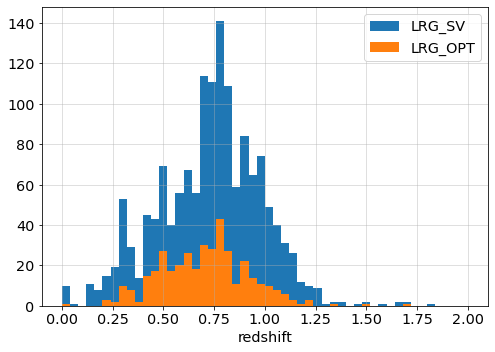

In [33]:
plt.figure(figsize=(8, 5.5))
plt.hist(zbest['Z'][lrg_sv & mask_zwarn],  50, range=(0, 2.), label='LRG_SV')
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], 50, range=(0, 2.), label='LRG_OPT')
plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

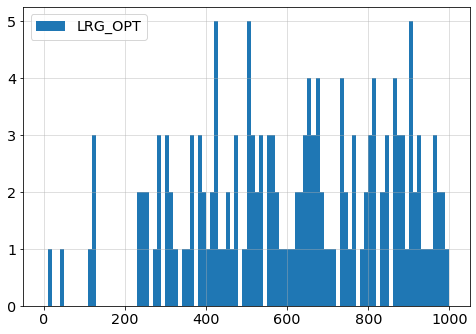

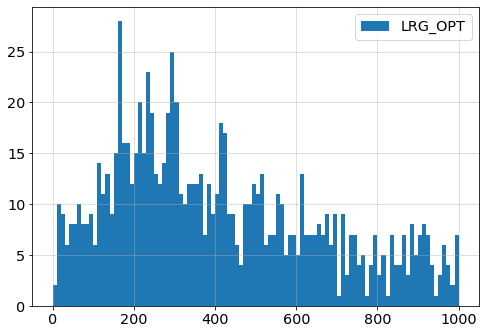

In [34]:
plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_opt & mask_zwarn], 100, range=(0, 1000.), label='LRG_OPT')
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_sv & mask_zwarn], 100, range=(0, 1000.), label='LRG_OPT')
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

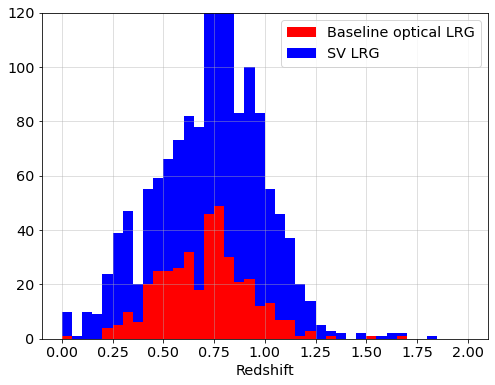

In [35]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.ylim(0, 120)
plt.show()

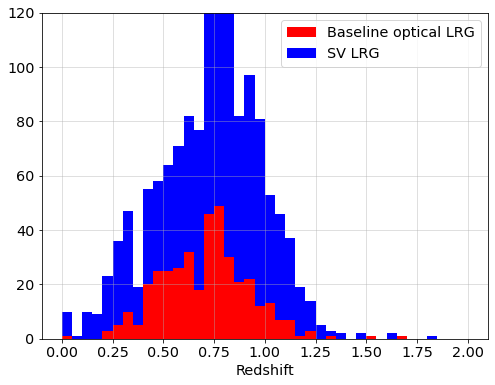

In [36]:
mask_dchi2 = zbest['DELTACHI2']>50

plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.ylim(0, 120)

plt.show()

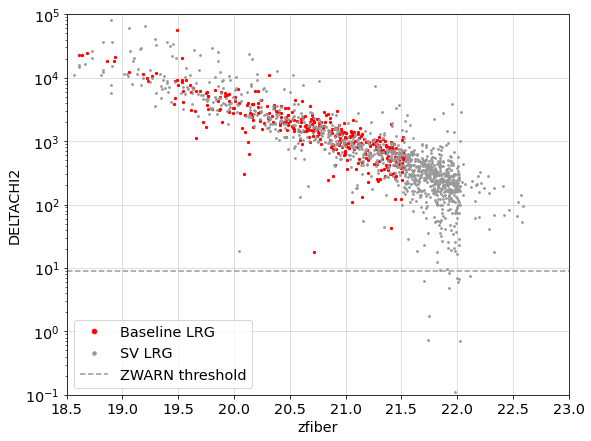

In [37]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

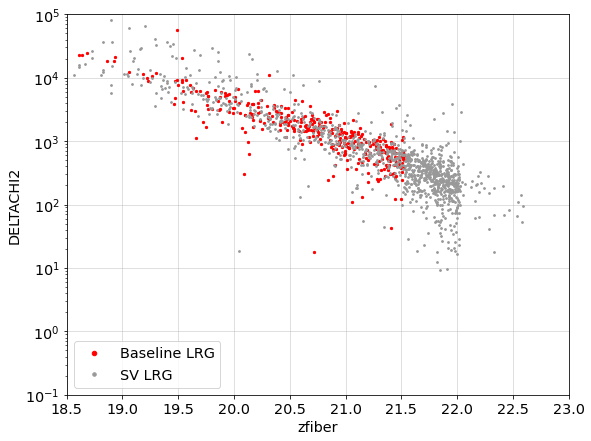

In [38]:
# Add ZWARN cut
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt & mask_zwarn], zbest['DELTACHI2'][lrg_opt & mask_zwarn], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv & mask_zwarn], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv & mask_zwarn], 'b.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

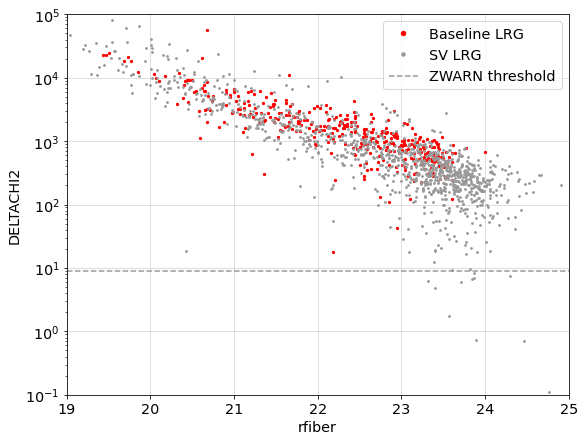

In [39]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['rfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['rfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('rfiber')
plt.ylabel('DELTACHI2')
plt.axis([19, 25, .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

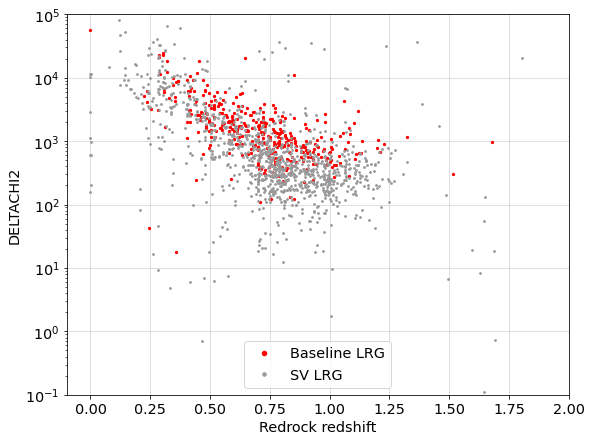

In [40]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['Z'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['Z'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.yscale('log')
plt.xlabel('Redrock redshift')
plt.ylabel('DELTACHI2')
plt.axis([-0.1, 2, .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()